Let's import the necessary libraries

In [1]:
import pandas as pd # Used for data manipulation
import matplotlib.pyplot as plt # Used for plotting
import seaborn as sns # Used for plotting
from huggingface_hub import login # Used to log in to Hugging Face and access datasets
from sentence_transformers import SentenceTransformer # Used for encoding sentences into vector representations
from transformers import pipeline # Used for using pre-trained models from Hugging Face for sentiment analysis
from sklearn.model_selection import train_test_split # Used for splitting the dataset into training and testing sets
from sklearn.ensemble import RandomForestClassifier # Used for training a Random Forest classifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, recall_score, precision_score # Used for evaluating the performance of the model

We will again use a pre-labeled dataset for sentence-level sentiment analysis of ECB speeches [@Pfeifer2023], which is available on Hugging Face ([Central Bank Communication Dataset](https://huggingface.co/datasets/Moritz-Pfeifer/CentralBankCommunication)). The dataset contains sentences from ECB speeches that have been labeled as positive or negative in terms of sentiment.

Let's load the dataset into a pandas DataFrame

In [2]:
df = pd.read_csv("hf://datasets/Moritz-Pfeifer/CentralBankCommunication/Sentiment/ECB_prelabelled_sent.csv")

Since we have explored the dataset in the NLP chapter, we will not go into detail about its structure here. Instead, we will focus on how to encode the sentences into vector representations using a pre-trained sentence transformer model.


### Encoding Sentences with a Pre-trained Sentence Transformer

Suppose we want to get a dense vector representation of sentences that we can use for various downstream tasks, e.g., as input features for a machine learning model. We can use a pre-trained sentence transformer model from the Hugging Face library to achieve this.

First, we need to load the pre-trained model. We will use the "all-MiniLM-L6-v2" model, which is a small embedding model that does not require a GPU and can be run on a CPU. 

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Consider the following example sentences

In [4]:
sentences = [
    "The ECB's monetary policy is not very effective for stabilizing the economy.",
    "The ECB's monetary policy is very ineffective for stabilizing the economy."
]

We can encode these sentences into vector representations using the `encode` method of the model. This will give us a dense vector for each sentence.

In [5]:
embeddings = model.encode(sentences)
print(embeddings.shape)

(2, 384)


The output will show the shape of the embeddings, which should be (2, 384) since we have 2 sentences and the "all-MiniLM-L6-v2" model produces 384-dimensional embeddings. We can also compute the cosine similarity between the embeddings of the two sentences to see how similar they are in terms of their vector representations.

In [6]:
similarities = model.similarity(embeddings, embeddings)
print(similarities)

tensor([[1.0000, 0.9408],
        [0.9408, 1.0000]])


Let's now apply this encoding to the sentences in our dataset. We will encode all sentences in the "text" column of our DataFrame and store the resulting embeddings in a new column called "embedding".

In [7]:
df["embedding"] = list(model.encode(df["text"].tolist()))

Note that we did not do any preprocessing of the text before encoding, as the sentence transformer model can handle raw text input, and does not require tokenization or other preprocessing steps. The model will take care of that internally when encoding the sentences.


### Using Sentence Embeddings for Sentiment Analysis

Let's use the sentence embeddings as input features for a machine learning model to perform sentiment analysis. We will use a simple Random Forest classifier for this task. First, we need to split the dataset into a training set and a testing set

In [8]:
X = df['embedding'].to_list() # Convert the embeddings from a pandas Series to a list of numpy arrays
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # We use 20% of the data for testing, set a random state for reproducibility, and stratify to maintain class balance

Then, we can train a Random Forest classifier on the training data

In [9]:
clf_rf = RandomForestClassifier(n_estimators=100, random_state = 42).fit(X_train, y_train)

To evaluate the performance of the model, we can make predictions on the testing set and calculate metrics such as accuracy, precision, and recall

In [10]:
y_pred_rf = clf_rf.predict(X_test)
y_proba_rf = clf_rf.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall: {recall_score(y_test, y_pred_rf)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_rf[:, 1])}")

Accuracy: 0.9512670565302144
Precision: 0.9560439560439561
Recall: 0.9109947643979057
ROC AUC: 0.9940977529186044


Our machine learning model does perform much better than using the classical TF-IDF features, which we used in the NLP chapter. This shows that the sentence embeddings from the pre-trained model capture more meaningful information about the sentences, which allows the Random Forest classifier to make better predictions about the sentiment of the sentences.

We can also look at the confusion matrix to see how well the model is performing in terms of true positives, true negatives, false positives, and false negatives

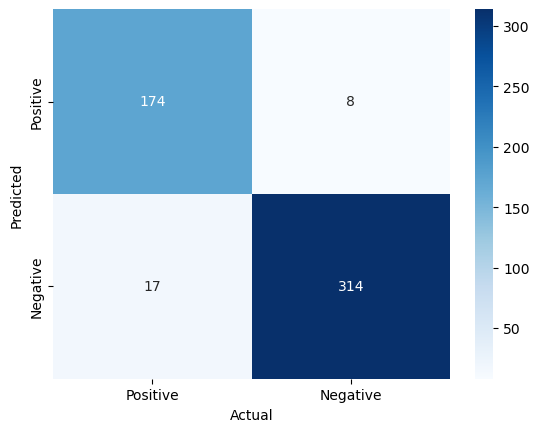

In [11]:
conf_mat = confusion_matrix(y_test, y_pred_rf, labels=[1, 0]).transpose() # Transpose the sklearn confusion matrix to match the convention in the lecture
sns.heatmap(conf_mat, annot=True, cmap='Blues', fmt='g', xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

### Using Pre-trained Models from Hugging Face for Sentiment Analysis

Instead of using the sentence embeddings as input features for a separate machine learning model, we can also directly use a pre-trained model from Hugging Face that is fine-tuned for sentiment analysis.

In [12]:
analyzer = pipeline("sentiment-analysis") 
result = analyzer("The ECB's monetary policy is very ineffective for stabilizing the economy.")
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Device set to use mps:0


[{'label': 'NEGATIVE', 'score': 0.9997608065605164}]


This uses a pre-trained model that has been fine-tuned on a large dataset for sentiment analysis. The output will show the predicted label (e.g., "NEGATIVE") and the confidence score for that prediction. To see which model is being used, we can check the default model used by the pipeline

In [13]:
print(analyzer.model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


We can see that it is using DistilBERT as the model for sentiment analysis. 

Let's apply this sentiment analysis pipeline to the sentences in our dataset and see how well it performs compared to our Random Forest classifier that used sentence embeddings as features.

In [14]:
results = analyzer(df["text"].tolist(), batch_size=32)
df["hf_sentiment"] = [int(r['label'] == "POSITIVE") for r in results]
df["hf_score"] = [r['score'] if r['label'] == "POSITIVE" else 1 - r['score'] for r in results]

Now we can evaluate the performance of the Hugging Face sentiment analysis model using the same metrics as before

In [15]:
test_idx = y_test.index
print(f"Accuracy: {accuracy_score(df.loc[test_idx, 'sentiment'], df.loc[test_idx, 'hf_sentiment'])}")
print(f"Precision: {precision_score(df.loc[test_idx, 'sentiment'], df.loc[test_idx, 'hf_sentiment'])}")
print(f"Recall: {recall_score(df.loc[test_idx, 'sentiment'], df.loc[test_idx, 'hf_sentiment'])}")
print(f"ROC AUC: {roc_auc_score(df.loc[test_idx, 'sentiment'], df.loc[test_idx, 'hf_score'])}")

Accuracy: 0.9298245614035088
Precision: 0.863849765258216
Recall: 0.9633507853403142
ROC AUC: 0.9794478228350298


The performance of the Hugging Face model is not quite as good as our Random Forest classifier that used sentence embeddings. This is likely due to the fact that the pre-trained model was not fine-tuned on our specific dataset of ECB speeches but on movie reviews. 


:::{.callout-note}

#### Fine-Tuning Pre-trained Models

The transformers library also allows us to fine-tune pre-trained models on our specific dataset, which can significantly improve the performance of the model for our specific task. However, fine-tuning a large language model can be computationally expensive and may require access to a GPU. Therefore, we will not cover the fine-tuning process in this lecture, but it is an important topic to explore if you want to achieve the best possible performance on your specific task.

:::


### Other NLP Tasks with Pre-trained Models 

The transformers library can also be used for many other NLP tasks. For example, we can use a pre-trained model for text generation

In [16]:
generator = pipeline(model="openai-community/gpt2")
generator("The ECB's monetary policy is very", do_sample=False)

Device set to use mps:0


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "The ECB's monetary policy is very important. It is important to understand that the ECB is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not a central bank. It is not 

In this example, we are using a pre-trained GPT-2 model to generate text based on the input prompt "The ECB's monetary policy is very".

We can also use a pre-trained model for zero-shot classification, which allows us to classify text into categories without having to fine-tune the model on a specific dataset

In [17]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

Device set to use mps:0


Using this zero-shot classification pipeline, we can classify sentences into categories based on the content of the sentences, even if the model has not been specifically trained on those categories. For example, we can classify sentences from ECB speeches into categories such as "monetary policy", "fiscal policy", or "other" based on their content.

In [18]:
sequences_to_classify = [
    "The European Central Bank is committed to price stability.",
    "Governments need to run a balanced budget.",
    "Leslie Nielsen was a great actor."]
candidate_labels = ["monetary policy", "fiscal policy", "other"]

for sequence in sequences_to_classify:
    result = classifier(sequence, candidate_labels)

    print(f"Sequence: {sequence}")
    print(f"Predicted label: {result['labels'][0]}")
    print(f"Confidence score: {result['scores'][0]:.4f}")
    print("------")

Sequence: The European Central Bank is committed to price stability.
Predicted label: monetary policy
Confidence score: 0.9034
------


Sequence: Governments need to run a balanced budget.
Predicted label: fiscal policy
Confidence score: 0.8744
------


Sequence: Leslie Nielsen was a great actor.
Predicted label: other
Confidence score: 0.8404
------
